/usr/lib/python3/dist-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ndim = x[:, None].ndim
/usr/lib/python3/dist-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


6.0


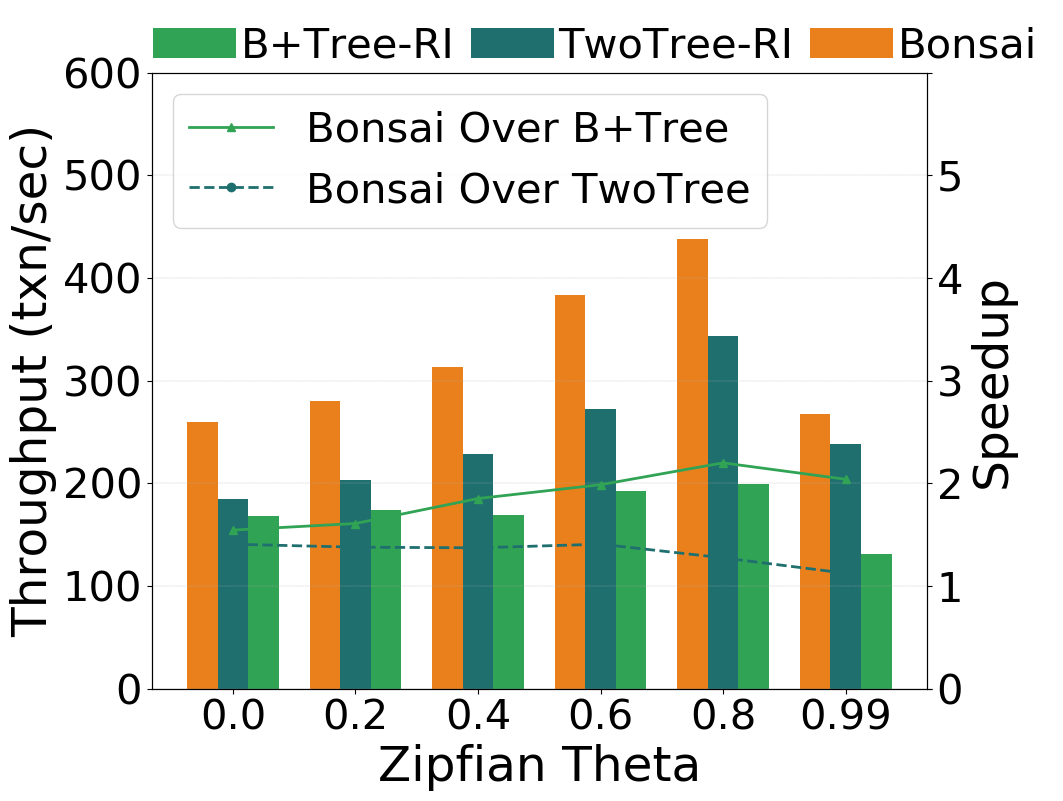

In [9]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from process_helper import select_color_idx


txtsize=35
ticksize=30

color_indices, line_colors = select_color_idx(4)
bonsai_c = "#ea801c"
page_retain_c = "#31a354"
# page_retain_c = line_colors["BLUE"]
page_evict_c = "#78c679"
tt_retain_c = "#1f6f6f"
tt_evict_c = "#54a1a1"

bonsai_label = "Bonsai"
page_idx_label = "B+Tree-RI"
page_idx_evict_label = "B+Tree-EI" 
tt_idx_label = "TwoTree-RI"
tt_idx_evict_label = "TwoTree-EI"


datadir = "../../output/"
exp_page = "exp_point_10g_page_unihotspot_rw"
exp_page_idx_evict = "exp_point_10g_page_unihotspot_idx_evict_rw"
exp_tuple = "exp_point_10g_tuple_unihotspot_rw"
# exp_remote = "different_settings/" + "microbench_zipf_10g_fanout18.out"
exp_twotree = "exp_point_10g_twotree_unihotspot_rw"
exp_twotree_idx_evict = "exp_point_10g_twotree_unihotspot_idx_evict_rw"
x_dimension = "zipf_theta_"



# Load and prepare the data
data_page = [json.loads(line) for line in open(datadir + exp_page + ".txt")]
df_page = pd.DataFrame().from_records(data_page).sort_values(by=x_dimension)

data_page_idx_evict = [json.loads(line) for line in open(datadir + exp_page_idx_evict + ".txt")]
df_page_idx_evict = pd.DataFrame().from_records(data_page_idx_evict).sort_values(by=x_dimension)

data_tuple = [json.loads(line) for line in open(datadir + exp_tuple + ".txt")]
df_tuple = pd.DataFrame().from_records(data_tuple).sort_values(by=x_dimension)

data_tt = [json.loads(line) for line in open(datadir + exp_twotree + ".txt")]
df_tt = pd.DataFrame().from_records(data_tt).sort_values(by=x_dimension)

data_tt_idx_evict = [json.loads(line) for line in open(datadir + exp_twotree_idx_evict + ".txt")]
df_tt_idx_evict = pd.DataFrame().from_records(data_tt_idx_evict)
df_tt_idx_evict = df_tt_idx_evict.sort_values(by=x_dimension)

dimension = "throughput_txn_per_sec"

bar_width = 0.25
indices = np.arange(len(df_page))
offset = bar_width


fig, ax1 = plt.subplots(figsize=(10, 8))

# Bar chart for the primary data
# ax1.bar(indices + offset * 2, df_page_idx_evict[dimension], bar_width, label=page_idx_evict_label, color=page_evict_c)
ax1.bar(indices + offset, df_page[dimension], bar_width, label=page_idx_label, color=page_retain_c)
# ax1.bar(indices , df_tt_idx_evict[dimension], bar_width, label=tt_idx_evict_label, color=tt_evict_c)
ax1.bar(indices, df_tt[dimension], bar_width, label=tt_idx_label, color=tt_retain_c)
ax1.bar(indices - offset, df_tuple[dimension], bar_width, label=bonsai_label, color=bonsai_c)

ax1.set_xticks(indices)
ax1.set_xticklabels(df_page[x_dimension])
# ax1.set_yscale('log')
ax1.set_ylim(0, 600)
# ax1.set_ylim(bottom=1, top=y.max())

# ymin1, ymax1 = ax1.get_ylim()
# print(ymax1)
# ax1.set_yticks(list(ax1.get_yticks()) + [ymin1, ymax1])

# ax1.set_xscale('log')
ax1.tick_params(axis='both', labelsize=ticksize)
ax1.set_ylabel("Throughput (txn/sec)", fontsize=txtsize)
ax1.set_xlabel("Zipfian Theta", fontsize=txtsize)
ax1.grid(axis='y', linestyle='--', linewidth=0.25)


# legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2, ncol=3, borderaxespad=0., handletextpad=0.4, labelspacing=0.2, columnspacing=0.5, frameon=False)
legend = ax1.legend(fontsize=ticksize, bbox_to_anchor=(-0.02, 1.0, 1.1, .102), loc=2,
           ncol=3,borderaxespad=0., frameon=False,columnspacing=0.4, handletextpad=0.1)

# Secondary y-axis for Bonsai's speedup calculation
ax2 = ax1.twinx()

# Calculate speedup of Bonsai over Page-IdxRetain and TwoTree-IdxRetain
speedup_page = df_tuple[dimension] / df_page[dimension]
speedup_tt = df_tuple[dimension] / df_tt[dimension]

# Plot speedup as a line chart on the secondary y-axis
ax2.plot(indices, speedup_page, color=page_retain_c, marker='^', label='Bonsai Over B+Tree', linewidth=2)
ax2.plot(indices, speedup_tt, color=tt_retain_c, marker='o', label='Bonsai Over TwoTree', linestyle='dashed', linewidth=2)

ax2.set_ylabel('Speedup', fontsize=txtsize)

ymax = 6
ax2.set_yticks(np.arange(0,ymax, 1))
ax2.set_ylim(0, ymax)
# ax2.set_yticks(np.arange(0, 25, 2))
ax2.set_yticklabels(np.arange(0, ymax, 1), fontsize=ticksize)
ax2.legend(loc='upper left', fontsize=ticksize)
ymin1, ymax1 = ax2.get_ylim()
print(ymax1)
ax2.set_yticks(list(ax2.get_yticks()) + [ymin1, ymax1])


# Legend
# ax1.legend(loc='upper left')

plt.savefig("/home/hippo/Bonsai-private/paper/experiment/ev1-skew-rw-tps.pdf",bbox_inches='tight')

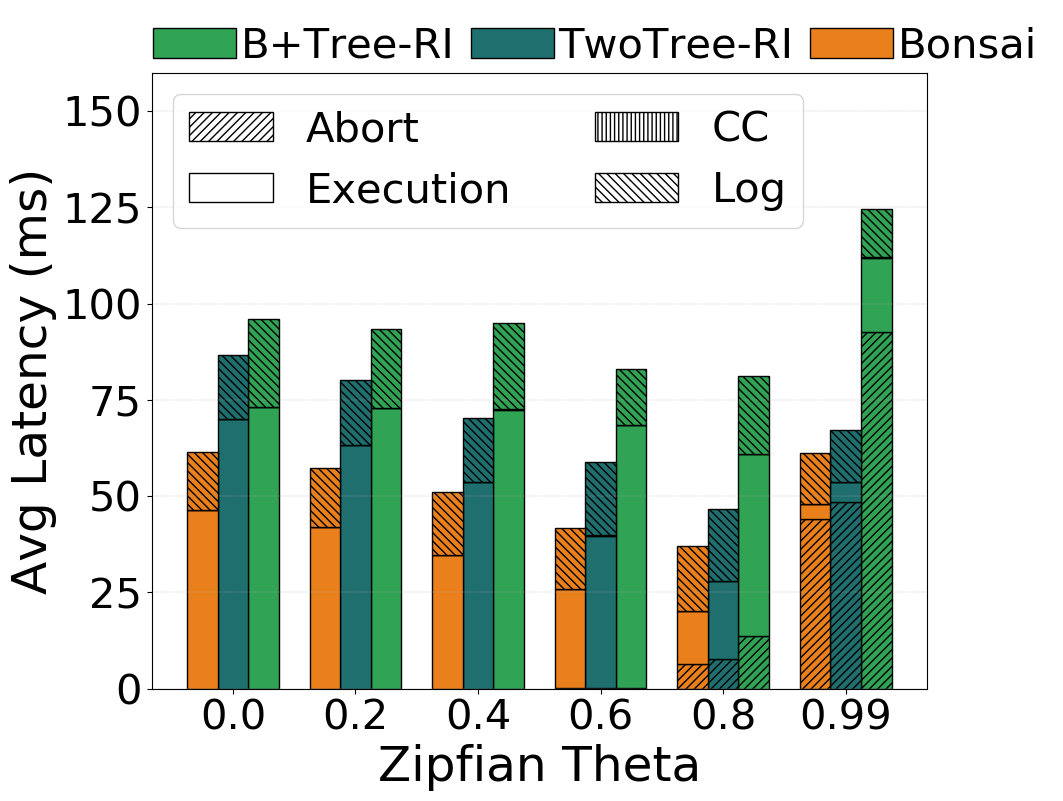

In [14]:
from matplotlib.patches import Patch
# fig, ax1 = plt.subplots(figsize=(12, 9.6))
fig, ax1 = plt.subplots(figsize=(10, 8))
offset = bar_width
# ax1 = fig.add_subplot(1, 1, 1)
index = np.arange(len(df_tuple["g_total_buf_sz"])) - offset * 3
indices = np.arange(len(df_page))
dimension = "avg_sum_txn_latency (us)"
cur_label="Page"
cur_color=page_retain_c
cur_df = df_page 
cur_exec_time = cur_df["avg_sum_rw_txn_latency (us)"] - cur_df["avg_log_time_ (us)"] - cur_df["avg_rw_abort_time_ (us)"] - cur_df["avg_cc_time_ (us)"] 
cur_idx = 2
barloc = indices + offset

ax1.bar(barloc, 
        cur_df["avg_rw_abort_time_ (us)"]/1000.0 , width=bar_width,edgecolor='black', hatch='////',
        color=cur_color,
        label=cur_label+"-Abort-Time")
ax1.bar(barloc, 
        cur_exec_time/1000.0, bottom=cur_df["avg_rw_abort_time_ (us)"]/1000.0, width=bar_width, edgecolor='black',
        color=cur_color,
        label=cur_label+"-Execution-Time")
ax1.bar(barloc, 
        cur_df["avg_cc_time_ (us)"]/1000.0, bottom=[(i+j)/1000.0 for i, j in zip(cur_df["avg_rw_abort_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='||||',
        color=cur_color,
        label=cur_label+"-CC-Time")
ax1.bar(barloc, 
        cur_df["avg_log_time_ (us)"]/1000.0, bottom=[(i+j+m)/1000.0 for i, j, m in zip(cur_df["avg_rw_abort_time_ (us)"], cur_df["avg_cc_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='\\\\\\\\',
        color=cur_color,
        label=cur_label+"-Log-Time")

# cur_label="Page"
# cur_color=page_evict_c
# cur_df = df_page_idx_evict 
# cur_exec_time = cur_df["avg_sum_rw_txn_latency (us)"] - cur_df["avg_log_time_ (us)"] - cur_df["avg_rw_abort_time_ (us)"] - cur_df["avg_cc_time_ (us)"] 
# cur_idx = 3
# barloc = indices + offset * 2

# ax1.bar(barloc, 
#         cur_df["avg_rw_abort_time_ (us)"]/1000.0 , width=bar_width,edgecolor='black', hatch='////',
#         color=cur_color,
#         label=cur_label+"-Abort-Time")
# ax1.bar(barloc, 
#         cur_exec_time/1000.0, bottom=cur_df["avg_rw_abort_time_ (us)"]/1000.0, width=bar_width, edgecolor='black',
#         color=cur_color,
#         label=cur_label+"-Execution-Time")
# ax1.bar(barloc, 
#         cur_df["avg_cc_time_ (us)"]/1000.0, bottom=[(i+j)/1000.0 for i, j in zip(cur_df["avg_rw_abort_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='||||',
#         color=cur_color,
#         label=cur_label+"-CC-Time")
# ax1.bar(barloc, 
#         cur_df["avg_log_time_ (us)"]/1000.0, bottom=[(i+j+m)/1000.0 for i, j, m in zip(cur_df["avg_rw_abort_time_ (us)"], cur_df["avg_cc_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='\\\\\\\\',
#         color=cur_color,
#         label=cur_label+"-Log-Time")

cur_label="TwoTree"
cur_color=tt_retain_c
cur_df = df_tt 
cur_exec_time = cur_df["avg_sum_rw_txn_latency (us)"] - cur_df["avg_log_time_ (us)"] - cur_df["avg_rw_abort_time_ (us)"] - cur_df["avg_cc_time_ (us)"] 
cur_idx = 4
barloc = indices

ax1.bar(barloc, 
        cur_df["avg_rw_abort_time_ (us)"]/1000.0 , width=bar_width,edgecolor='black', hatch='////',
        color=cur_color,
        label=cur_label+"-Abort-Time")
ax1.bar(barloc, 
        cur_exec_time/1000.0, bottom=cur_df["avg_rw_abort_time_ (us)"]/1000.0, width=bar_width, edgecolor='black',
        color=cur_color,
        label=cur_label+"-Execution-Time")
ax1.bar(barloc, 
        cur_df["avg_cc_time_ (us)"]/1000.0, bottom=[(i+j)/1000.0 for i, j in zip(cur_df["avg_rw_abort_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='||||',
        color=cur_color,
        label=cur_label+"-CC-Time")
ax1.bar(barloc, 
        cur_df["avg_log_time_ (us)"]/1000.0, bottom=[(i+j+m)/1000.0 for i, j, m in zip(cur_df["avg_rw_abort_time_ (us)"], cur_df["avg_cc_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='\\\\\\\\',
        color=cur_color,
        label=cur_label+"-Log-Time")


# cur_label="TwoTree"
# cur_color=tt_evict_c
# cur_df = df_tt_idx_evict
# cur_exec_time = cur_df["avg_sum_rw_txn_latency (us)"] - cur_df["avg_log_time_ (us)"] - cur_df["avg_rw_abort_time_ (us)"] - cur_df["avg_cc_time_ (us)"] 
# cur_idx = 5
# barloc = indices
# ax1.bar(barloc, 
#         cur_df["avg_rw_abort_time_ (us)"]/1000.0 , width=bar_width,edgecolor='black', hatch='////',
#         color=cur_color,
#         label=cur_label+"-Abort-Time")
# ax1.bar(barloc, 
#         cur_exec_time/1000.0, bottom=cur_df["avg_rw_abort_time_ (us)"]/1000.0, width=bar_width, edgecolor='black',
#         color=cur_color,
#         label=cur_label+"-Execution-Time")
# ax1.bar(barloc, 
#         cur_df["avg_cc_time_ (us)"]/1000.0, bottom=[(i+j)/1000.0 for i, j in zip(cur_df["avg_rw_abort_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='||||',
#         color=cur_color,
#         label=cur_label+"-CC-Time")
# ax1.bar(barloc, 
#         cur_df["avg_log_time_ (us)"]/1000.0, bottom=[(i+j+m)/1000.0 for i, j, m in zip(cur_df["avg_rw_abort_time_ (us)"], cur_df["avg_cc_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='\\\\\\\\',
#         color=cur_color,
#         label=cur_label+"-Log-Time")

cur_label="Bonsai"
cur_color=bonsai_c
cur_df = df_tuple 
cur_exec_time = cur_df["avg_sum_rw_txn_latency (us)"] - cur_df["avg_log_time_ (us)"] - cur_df["avg_rw_abort_time_ (us)"] - cur_df["avg_cc_time_ (us)"] 
cur_idx = 1
barloc = indices - offset 
ax1.bar(barloc, 
        cur_df["avg_rw_abort_time_ (us)"]/1000.0 , width=bar_width,edgecolor='black', hatch='////',
        color=cur_color,
        label=cur_label+"-Abort-Time")
ax1.bar(barloc, 
        cur_exec_time/1000.0, bottom=cur_df["avg_rw_abort_time_ (us)"]/1000.0, width=bar_width, edgecolor='black',
        color=cur_color,
        label=cur_label+"-Execution-Time")
ax1.bar(barloc, 
        cur_df["avg_cc_time_ (us)"]/1000.0, bottom=[(i+j)/1000.0 for i, j in zip(cur_df["avg_rw_abort_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='||||',
        color=cur_color,
        label=cur_label+"-CC-Time")
ax1.bar(barloc, 
        cur_df["avg_log_time_ (us)"]/1000.0, bottom=[(i+j+m)/1000.0 for i, j, m in zip(cur_df["avg_rw_abort_time_ (us)"], cur_df["avg_cc_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='\\\\\\\\',
        color=cur_color,
        label=cur_label+"-Log-Time")

# plt.xticks(index + bar_width * (5 - 1) / 2,df_tuple["g_total_buf_sz"]*100/(12*1000*1000*1000))

# location = "upper left"
location = "best"
# ax1.legend(loc=location, frameon=False)
ax1.set_ylabel("Avg Latency (ms)", fontsize=txtsize)
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
ax1.set_xlabel("Zipfian Theta", fontsize=txtsize)


ax1.set_xticks(indices)
ax1.set_xticklabels(df_page[x_dimension])
# ax1.set_xscale('log')
# ax1.set_yscale('log')
ax1.tick_params(axis='both', labelsize=ticksize)

subcategories = ['Abort', 'Execution', 'CC', 'Log']  # Stacks within each bar
bar_labels = [ page_idx_label, tt_idx_label, bonsai_label]  # Bars within each group


# Colors for the bars (categories)
colors = [page_retain_c, tt_retain_c,bonsai_c]

# Hatches for the subcategories
hatches = ['////', '', '||||', '\\\\\\\\']

# Create custom patches for the subcategories
hatch_patches = [Patch(facecolor='white', edgecolor='black', hatch=h, label=sc)
                 for h, sc in zip(hatches, subcategories)]

# Create custom patches for the categories
color_patches = [Patch(facecolor=c, edgecolor='black', label=bl)
                 for c, bl in zip(colors, bar_labels)]
ax1.set_ylim(0, 160)

# Create legends
subcat_legend = plt.legend(ncol=2, handles=hatch_patches,fontsize=ticksize, loc="upper left",)
ax1.add_artist(subcat_legend)  # Add the first legend manually to keep it when adding the second
# plt.legend(handles=color_patches, bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2,
#            ncol=3,borderaxespad=0.,handletextpad=0.4,labelspacing=0.2, columnspacing=0.5, frameon=False)
legend = plt.legend(handles=color_patches, fontsize=ticksize, bbox_to_anchor=(-0.02, 1.0, 1.1, .102), loc=2,
           ncol=3,borderaxespad=0., frameon=False,columnspacing=0.4, handletextpad=0.1)




# # Secondary y-axis for Bonsai's speedup calculation
# ax2 = ax1.twinx()

# # Calculate speedup of Bonsai over Page-IdxRetain and TwoTree-IdxRetain
# page_tps = np.minimum(df_page[dimension], df_page_idx_evict[dimension])
# tt_tps =np.minimum(df_tt[dimension], df_tt_idx_evict[dimension]) 

# speedup_page = page_tps/ df_tuple[dimension] 
# speedup_tt = tt_tps/ df_tuple[dimension] 
# # print(df_page["throughput_txn_per_sec"])
# # print(page_tps)

# # Plot speedup as a line chart on the secondary y-axis
# ax2.plot(indices, speedup_page, color=page_retain_c, marker='^', label='Bonsai Over B+Tree', linewidth=2)
# ax2.plot(indices, speedup_tt, color=tt_retain_c, marker='o', label='Bonsai Over TwoTree', linestyle='dashed', linewidth=2)

# ax2.set_ylabel('Speedup')
# # ax2.set_yscale('log')
# ax2.set_yticks(np.arange(0, 8, 2))
# ax2.set_ylim(0, 4)
# ax2.legend(loc='upper right', fontsize=ticksize)

# ymax = 5
# ax2.set_ylabel('Speedup', fontsize=txtsize)
# # ax2.set_yscale('log')
# ax2.set_yticks(np.arange(0, ymax, 1))
# ax2.set_yticklabels(np.arange(0, ymax, 1), fontsize=ticksize)
# ax2.set_ylim(0, ymax)

# Legend
# ax1.legend(loc='upper left')

plt.savefig("/home/hippo/Bonsai-private/paper/experiment/ev1-skew-rw-analysis-latency-breakdown.pdf", bbox_inches='tight')


/usr/lib/python3/dist-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ndim = x[:, None].ndim
/usr/lib/python3/dist-packages/matplotlib/axes/_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
/usr/lib/python3/dist-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


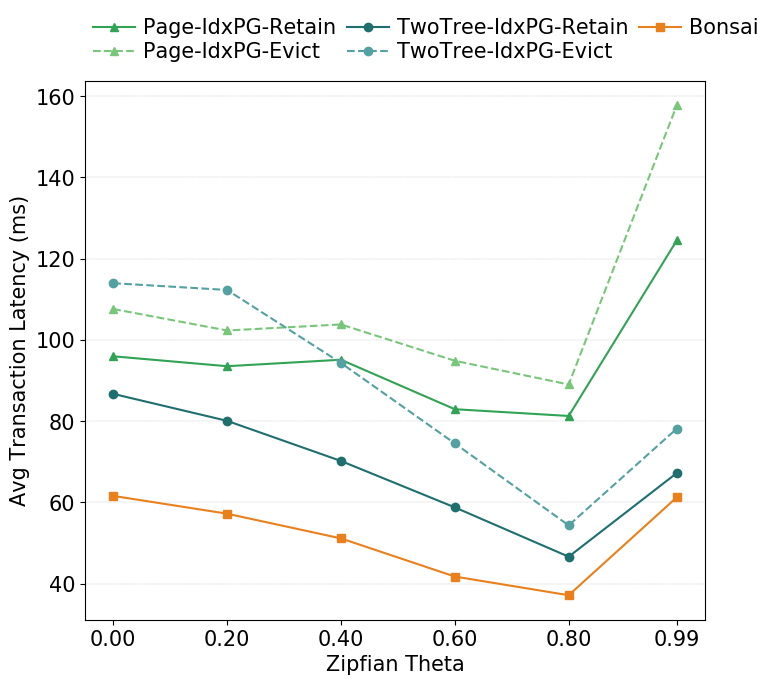

In [2]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(1, 1, 1)


# ax.plot(df_tuple[x_label] , 
#         df_tuple["txn_latency_perc99_us"]/1000,
#         # df_tuple["avg_sum_txn_latency (us)"]/1000,
#         color=line_colors["BLUE"],
#         marker="s", label="Bonsai", linestyle='dashed')


ax.plot(df_page[x_label] , 
    # df_tuple["txn_latency_perc99_us"]/1000,
        df_page["avg_sum_txn_latency (us)"]/1000,
        color=page_retain_c,
        marker="^", label="Page-IdxPG-Retain")

# # # # Annotate each data point with its corresponding value
# # # for i in range(len(df_page[x_label])):
# # #     plt.annotate(f'{df_page["throughput_txn_per_sec"][i]:.2f}', (df_page[x_label][i], df_page["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

ax.plot(df_page_idx_evict[x_label] , 
    # df_page_idx_evict["txn_latency_perc99_us"]/1000,
        df_page_idx_evict["avg_sum_txn_latency (us)"]/1000,
        color=page_evict_c,
        marker="^", label="Page-IdxPG-Evict", linestyle='dashed')
# # print(df_page["throughput_txn_per_sec"])
# # # Annotate each data point with its corresponding value
# # for i in range(len(df_page_idx_evict[x_label])):
# #     plt.annotate(f'{df_page_idx_evict["throughput_txn_per_sec"][i]:.2f}', (df_page_idx_evict[x_label][i], df_page_idx_evict["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

#     #     ax.plot(xval, 
#     #             plot_data3.loc[y]["throughput_txn_per_sec"],
#     #             color=line_colors["ORANGE"],
#     #             marker=".", label="Remote-Index")

ax.plot(df_tt[x_label] , 
  # df_tt["txn_latency_perc99_us"]/1000,
        df_tt["avg_sum_txn_latency (us)"]/1000,
        color=tt_retain_c,
        marker="o", label="TwoTree-IdxPG-Retain")
ax.plot(df_tt_idx_evict[x_label] , 
  # df_tt_idx_evict["txn_latency_perc99_us"]/1000,
        df_tt_idx_evict["avg_sum_txn_latency (us)"]/1000,
        color=tt_evict_c,
        marker="o", label="TwoTree-IdxPG-Evict",  linestyle='dashed')
ax.plot(df_tuple[x_label] , 
        # df_tuple["txn_latency_perc99_us"]/1000,
        df_tuple["avg_sum_txn_latency (us)"]/1000,
        color=bonsai_c,
        marker="s", label="Bonsai")
# ax.set_ylim(0, 125)
#ax.set_xlim(0, 1)
ax.set_xticks(df_tuple[x_label])
# ax.set_xscale('log')
# ax.set_yscale('log')
location = "upper left"
# ax.legend(loc=location, frameon=False)
ax.set_ylabel("Avg Transaction Latency (ms)")
ax.set_xlabel("Zipfian Theta")
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2,
           ncol=3,borderaxespad=0.,handletextpad=0.4,labelspacing=0.2, columnspacing=0.5, frameon=False)
# ax.set_title("Avg Latency Varying Buffer Size (theta 0.9, writeheavy)")
plt.savefig("/home/hippo/Bonsai-private/paper/experiment/ev1-skew-rw-avg-latency.pdf",bbox_inches='tight')


/usr/lib/python3/dist-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ndim = x[:, None].ndim
/usr/lib/python3/dist-packages/matplotlib/axes/_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
/usr/lib/python3/dist-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


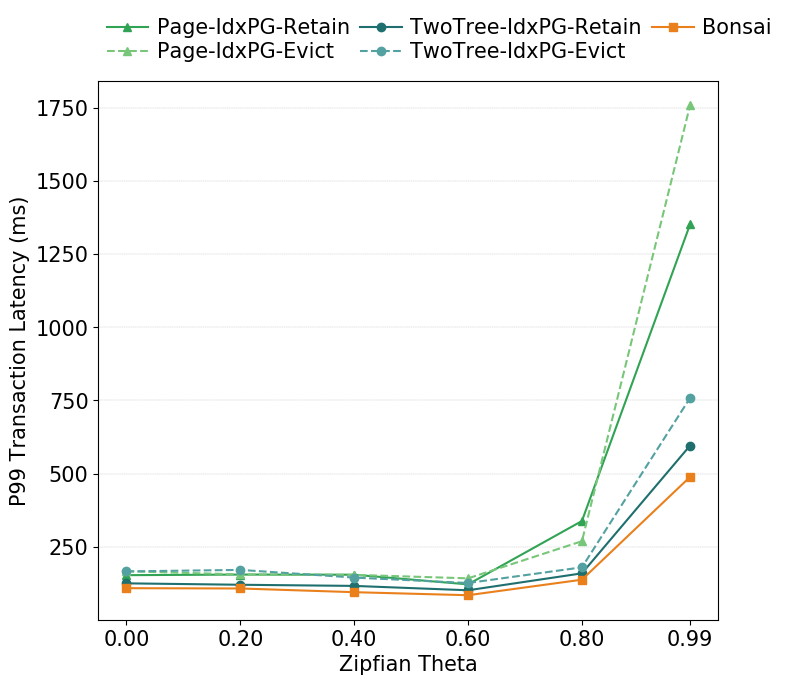

In [3]:

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(1, 1, 1)

# ax.plot(df_tuple[x_label] , 
#         # df_tuple["txn_latency_perc99_us"]/1000,
#         df_tuple["avg_sum_txn_latency (us)"]/1000,
#         color=line_colors["BLUE"],
#         marker="s", label="Bonsai")




ax.plot(df_page[x_label] , 
        df_page["txn_latency_perc99_us"]/1000,
        color=page_retain_c,
        marker="^", label="Page-IdxPG-Retain")

# # # # Annotate each data point with its corresponding value
# # # for i in range(len(df_page[x_label])):
# # #     plt.annotate(f'{df_page["throughput_txn_per_sec"][i]:.2f}', (df_page[x_label][i], df_page["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

ax.plot(df_page_idx_evict[x_label] , 
        df_page_idx_evict["txn_latency_perc99_us"]/1000,
        color=page_evict_c,
        marker="^", label="Page-IdxPG-Evict", linestyle='dashed')
# # print(df_page["throughput_txn_per_sec"])
# # # Annotate each data point with its corresponding value
# # for i in range(len(df_page_idx_evict[x_label])):
# #     plt.annotate(f'{df_page_idx_evict["throughput_txn_per_sec"][i]:.2f}', (df_page_idx_evict[x_label][i], df_page_idx_evict["throughput_txn_per_sec"][i]), textcoords="offset points", xytext=(0,10), ha='center')

#     #     ax.plot(xval, 
#     #             plot_data3.loc[y]["throughput_txn_per_sec"],
#     #             color=line_colors["ORANGE"],
#     #             marker=".", label="Remote-Index")

ax.plot(df_tt[x_label] , 
        df_tt["txn_latency_perc99_us"]/1000,
        color=tt_retain_c,
        marker="o", label="TwoTree-IdxPG-Retain")
ax.plot(df_tt_idx_evict[x_label] , 
        df_tt_idx_evict["txn_latency_perc99_us"]/1000,
        color=tt_evict_c,
        marker="o", label="TwoTree-IdxPG-Evict",  linestyle='dashed')
ax.plot(df_tuple[x_label] , 
        df_tuple["txn_latency_perc99_us"]/1000,
        # df_tuple["avg_sum_txn_latency (us)"]/1000,
        color=bonsai_c,
        marker="s", label="Bonsai")
# ax.set_ylim(0, 700)
#ax.set_xlim(0, 1)
ax.set_xticks(df_tuple[x_label] )
# ax.set_xscale('log')
# ax.set_yscale('log')
location = "upper left"
# ax.legend(loc=location, frameon=False)
ax.set_ylabel("P99 Transaction Latency (ms)")
ax.set_xlabel("Zipfian Theta")
# ax.set_title("buf_{}_read_{}{}".format(buf_ratio[0], read_names[j], read_ratio[j]))
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2,
           ncol=3,borderaxespad=0.,handletextpad=0.4,labelspacing=0.2, columnspacing=0.5, frameon=False)
# ax.set_title("P99 Latency Varying Buffer Size (theta 0.9, writeheavy)")
plt.savefig("/home/hippo/Bonsai-private/paper/experiment/ev1-skew-rw-p99-latency.pdf",bbox_inches='tight')



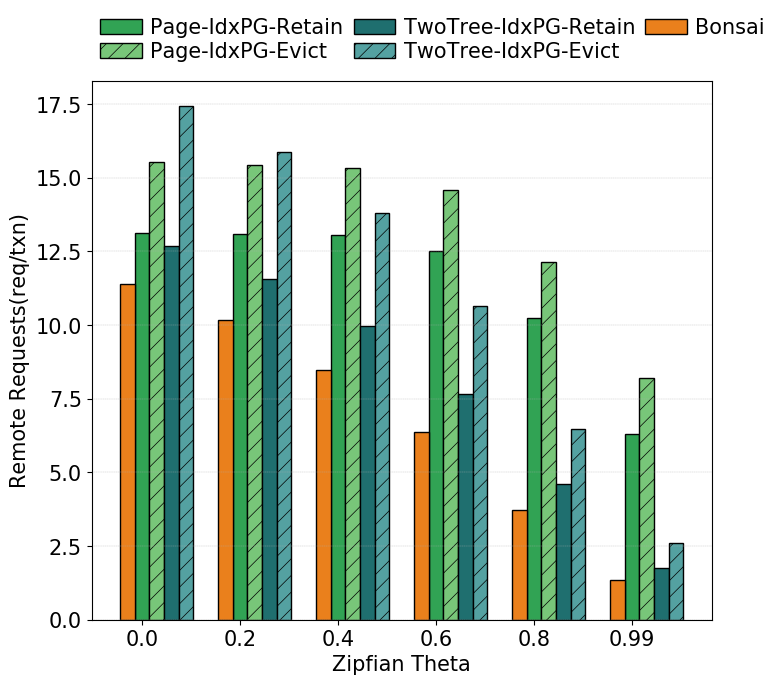

In [4]:


fig = plt.figure(figsize=(8, 7))


index = np.arange(len(df_tuple[x_label]))

bar_width = 0.15

# _, ax1 = plt.subplots()
ax1 = fig.add_subplot(1, 1, 1)




ax1.bar(index + 2 * bar_width, 
        df_page["misses_"]/df_page["txn_cnt_"], bar_width, edgecolor='black',
        color=page_retain_c,
        label="Page-IdxPG-Retain")
ax1.bar(index + 3 * bar_width, 
        df_page_idx_evict["misses_"]/df_page_idx_evict["txn_cnt_"], bar_width,edgecolor='black',
        color=page_evict_c,
        label="Page-IdxPG-Evict",hatch="//")
        # ax.plot(xval, 
        #         plot_data3.loc[y]["throughput_txn_per_sec"],
        #         color=line_colors["ORANGE"],
        #         marker=".", label="Remote-Index")

ax1.bar(index + 4 * bar_width, 
        df_tt["misses_"]/df_tt["txn_cnt_"], bar_width,edgecolor='black',
        color=tt_retain_c,
        label="TwoTree-IdxPG-Retain")
ax1.bar(index + 5 * bar_width, 
        df_tt_idx_evict["misses_"]/df_tt_idx_evict["txn_cnt_"],bar_width,edgecolor='black',
        color=tt_evict_c,
        label="TwoTree-IdxPG-Evict",hatch="//")
ax1.bar(index + 1 * bar_width, 
        df_tuple["misses_"]/df_tuple["txn_cnt_"] , bar_width,edgecolor='black',
        color=bonsai_c,
        label="Bonsai")

plt.xticks(index + bar_width * (5 - 1) / 2,df_tuple[x_label])

# location = "upper left"
location = "best"
# ax1.legend(loc=location, frameon=False)
ax1.set_ylabel("Remote Requests(req/txn)")
ax1.set_xlabel("Zipfian Theta")
# ax1.set_xscale('log')
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)

legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2,
           ncol=3,borderaxespad=0.,handletextpad=0.4,labelspacing=0.2, columnspacing=0.5, frameon=False)
plt.savefig("/home/hippo/Bonsai-private/paper/experiment/ev1-skew-rw-analysis-remote-reqs-num.pdf",bbox_inches='tight')

# ax1.set_title("Remote Requests Varying Buffer Size (theta 0.9, writeheavy)")
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
# fig1.set_size_inches(8, 6)
# fig.set_size_inches(8, 6)



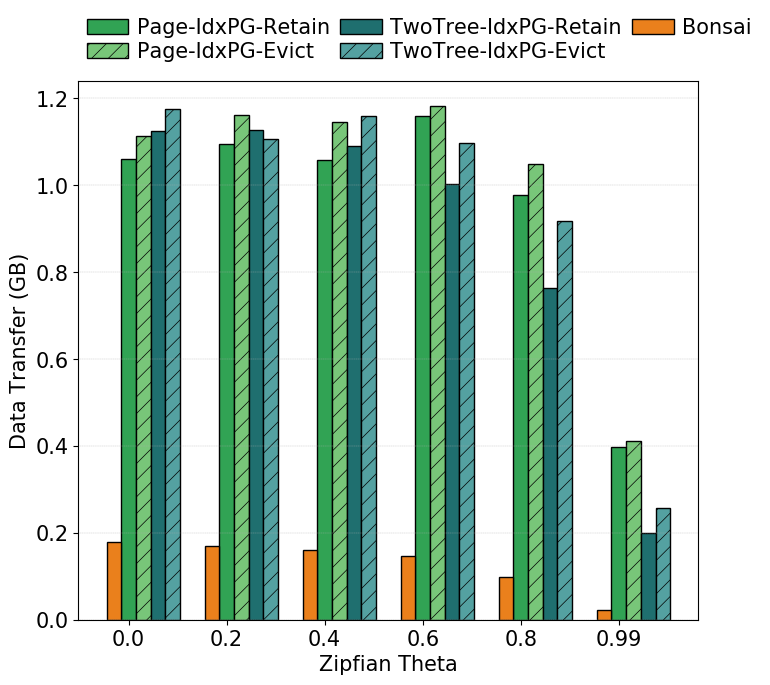

In [5]:
fig = plt.figure(figsize=(8, 7))

ax1 = fig.add_subplot(1, 1, 1)



ax1.bar(index + 2 * bar_width, 
        (df_page["misses_"])*8/1000000.0, bar_width, edgecolor='black',
        color=page_retain_c,
        label="Page-IdxPG-Retain")
ax1.bar(index + 3 * bar_width, 
        (df_page_idx_evict["misses_"])*8/1000000.0, bar_width,edgecolor='black',
        color=page_evict_c,
        label="Page-IdxPG-Evict",hatch="//")
        # ax.plot(xval, 
        #         plot_data3.loc[y]["throughput_txn_per_sec"],
        #         color=line_colors["ORANGE"],
        #         marker=".", label="Remote-Index")

ax1.bar(index + 4 * bar_width, 
        (df_tt["misses_"])*8/1000000.0, bar_width,edgecolor='black',
        color=tt_retain_c,
        label="TwoTree-IdxPG-Retain")
ax1.bar(index + 5 * bar_width, 
        (df_tt_idx_evict["misses_"])*8/1000000.0,bar_width,edgecolor='black',
        color=tt_evict_c,
        label="TwoTree-IdxPG-Evict",hatch="//")
ax1.bar(index + 1 * bar_width, 
        df_tuple["misses_"]/1000000.0, bar_width,edgecolor='black',
        color=bonsai_c,
        label="Bonsai")

plt.xticks(index + bar_width * (5 - 1) / 2,df_tuple[x_label])

# location = "upper left"
location = "best"
ax1.legend(loc=location, frameon=False)
ax1.set_ylabel("Data Transfer (GB)")
ax1.set_xlabel("Zipfian Theta")
# ax1.set_yscale('log')

# ax1.set_xscale('log')
# ax1.set_title("Data Transfer Varying Buffer Size (theta 0.9, writeheavy)")
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2,
           ncol=3,borderaxespad=0.,handletextpad=0.4,labelspacing=0.2, columnspacing=0.5, frameon=False)
plt.savefig("/home/hippo/Bonsai-private/paper/experiment/ev1-skew-rw-analysis-data-transfer.pdf",bbox_inches='tight')


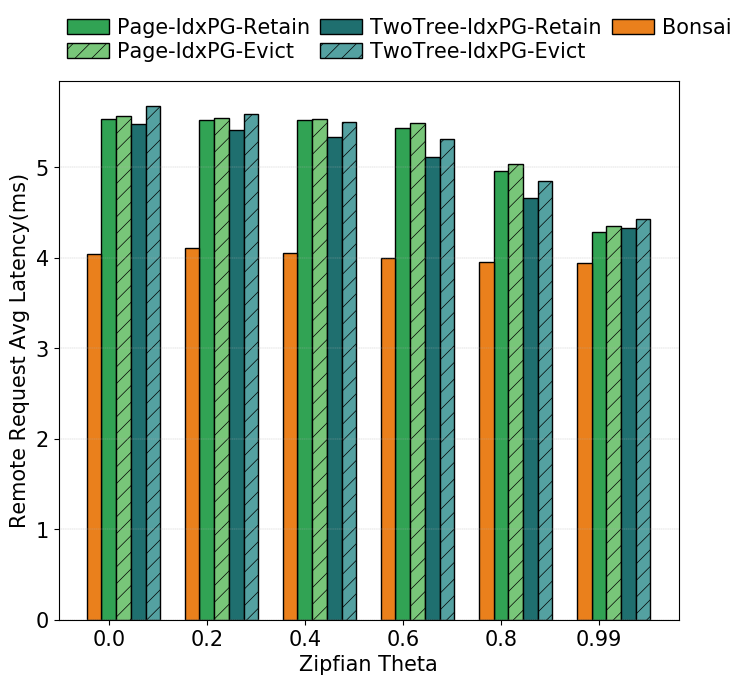

In [6]:

fig = plt.figure(figsize=(8, 7))

ax1 = fig.add_subplot(1, 1, 1)



ax1.bar(index + 2 * bar_width, 
        (df_page["remote_io_time_ms"])*1.0/df_page["remote_rds_"], bar_width, edgecolor='black',
        color=page_retain_c,
        label="Page-IdxPG-Retain")
ax1.bar(index + 3 * bar_width, 
        # (df_page_idx_evict["misses_"])*8/1000000.0, bar_width,edgecolor='black',
        ((df_page_idx_evict["remote_io_time_ms"])*1.0/df_page_idx_evict["remote_rds_"]), bar_width,edgecolor='black',
        color=page_evict_c,
        label="Page-IdxPG-Evict",hatch="//")
        # ax.plot(xval, 
        #         plot_data3.loc[y]["throughput_txn_per_sec"],
        #         color=line_colors["ORANGE"],
        #         marker=".", label="Remote-Index")

ax1.bar(index + 4 * bar_width, 
        # (df_tt["misses_"])*8/1000000.0, bar_width,edgecolor='black',
         (df_tt["remote_io_time_ms"])*1.0/df_tt["remote_rds_"], bar_width,edgecolor='black',
        color=tt_retain_c,
        label="TwoTree-IdxPG-Retain")
ax1.bar(index + 5 * bar_width, 
        # (df_tt_idx_evict["misses_"])*8/1000000.0,bar_width,edgecolor='black',
        ((df_tt_idx_evict["remote_io_time_ms"])*1.0/df_tt_idx_evict["remote_rds_"]),bar_width,edgecolor='black',
        color=tt_evict_c,
        label="TwoTree-IdxPG-Evict",hatch="//")
ax1.bar(index + 1 * bar_width, 
        df_tuple["remote_io_time_ms"]*1.0/df_tuple["remote_rds_"], bar_width,edgecolor='black',
        color=bonsai_c,
        label="Bonsai")
plt.xticks(index + bar_width * (5 - 1) / 2,df_tuple[x_label])

# location = "upper left"
location = "best"
# ax1.legend(loc=location, frameon=False)
ax1.set_ylabel("Remote Request Avg Latency(ms)")
ax1.set_xlabel("Zipfian Theta")
# ax1.set_yscale('log')

# ax1.set_xscale('log')
# ax1.set_title("Remote Request Avg Latency Varying Buffer Size (theta 0.9, writeheavy)")
#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2,
           ncol=3,borderaxespad=0.,handletextpad=0.4,labelspacing=0.2, columnspacing=0.5, frameon=False)
plt.savefig("/home/hippo/Bonsai-private/paper/experiment/ev1-skew-rw-analysis-remote-reqs-latency.pdf",bbox_inches='tight')


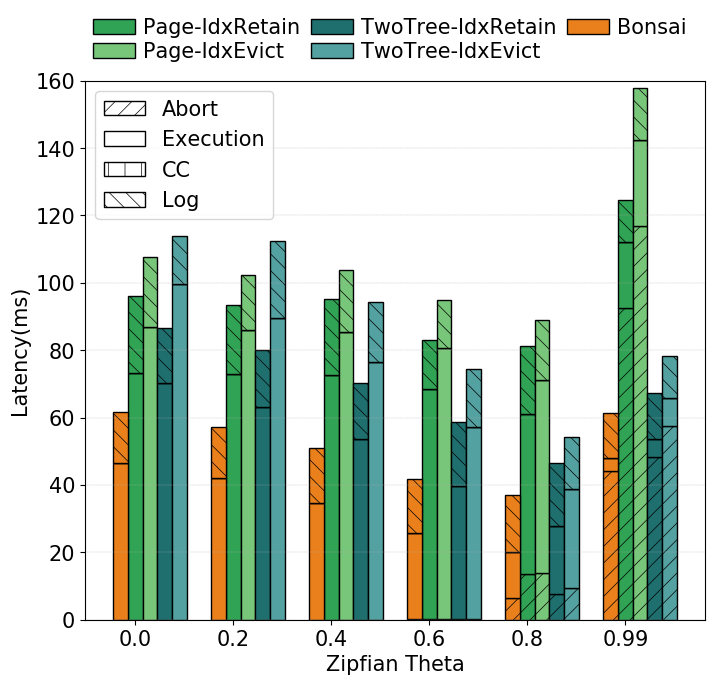

In [8]:
from matplotlib.patches import Patch
fig = plt.figure(figsize=(8, 7))

ax1 = fig.add_subplot(1, 1, 1)
index = np.arange(len(df_tuple[x_label]))

cur_label="Page"
cur_color=page_retain_c
cur_df = df_page 
cur_exec_time = cur_df["avg_sum_rw_txn_latency (us)"] - cur_df["avg_log_time_ (us)"] - cur_df["avg_rw_abort_time_ (us)"] - cur_df["avg_cc_time_ (us)"] 
cur_idx = 2
ax1.bar(index + cur_idx * bar_width, 
        cur_df["avg_rw_abort_time_ (us)"]/1000.0 , width=bar_width,edgecolor='black', hatch='////',
        color=cur_color,
        label=cur_label+"-Abort-Time")
ax1.bar(index + cur_idx * bar_width, 
        cur_exec_time/1000.0, bottom=cur_df["avg_rw_abort_time_ (us)"]/1000.0, width=bar_width, edgecolor='black',
        color=cur_color,
        label=cur_label+"-Execution-Time")
ax1.bar(index + cur_idx * bar_width, 
        cur_df["avg_cc_time_ (us)"]/1000.0, bottom=[(i+j)/1000.0 for i, j in zip(cur_df["avg_rw_abort_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='||||',
        color=cur_color,
        label=cur_label+"-CC-Time")
ax1.bar(index + cur_idx * bar_width, 
        cur_df["avg_log_time_ (us)"]/1000.0, bottom=[(i+j+m)/1000.0 for i, j, m in zip(cur_df["avg_rw_abort_time_ (us)"], cur_df["avg_cc_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='\\\\\\\\',
        color=cur_color,
        label=cur_label+"-Log-Time")

cur_label="Page"
cur_color=page_evict_c
cur_df = df_page_idx_evict 
cur_exec_time = cur_df["avg_sum_rw_txn_latency (us)"] - cur_df["avg_log_time_ (us)"] - cur_df["avg_rw_abort_time_ (us)"] - cur_df["avg_cc_time_ (us)"] 
cur_idx = 3
ax1.bar(index + cur_idx * bar_width, 
        cur_df["avg_rw_abort_time_ (us)"]/1000.0 , width=bar_width,edgecolor='black', hatch='////',
        color=cur_color,
        label=cur_label+"-Abort-Time")
ax1.bar(index + cur_idx * bar_width, 
        cur_exec_time/1000.0, bottom=cur_df["avg_rw_abort_time_ (us)"]/1000.0, width=bar_width, edgecolor='black',
        color=cur_color,
        label=cur_label+"-Execution-Time")
ax1.bar(index + cur_idx * bar_width, 
        cur_df["avg_cc_time_ (us)"]/1000.0, bottom=[(i+j)/1000.0 for i, j in zip(cur_df["avg_rw_abort_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='||||',
        color=cur_color,
        label=cur_label+"-CC-Time")
ax1.bar(index + cur_idx * bar_width, 
        cur_df["avg_log_time_ (us)"]/1000.0, bottom=[(i+j+m)/1000.0 for i, j, m in zip(cur_df["avg_rw_abort_time_ (us)"], cur_df["avg_cc_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='\\\\\\\\',
        color=cur_color,
        label=cur_label+"-Log-Time")

cur_label="TwoTree"
cur_color=tt_retain_c
cur_df = df_tt 
cur_exec_time = cur_df["avg_sum_rw_txn_latency (us)"] - cur_df["avg_log_time_ (us)"] - cur_df["avg_rw_abort_time_ (us)"] - cur_df["avg_cc_time_ (us)"] 
cur_idx = 4
ax1.bar(index + cur_idx * bar_width, 
        cur_df["avg_rw_abort_time_ (us)"]/1000.0 , width=bar_width,edgecolor='black', hatch='////',
        color=cur_color,
        label=cur_label+"-Abort-Time")
ax1.bar(index + cur_idx * bar_width, 
        cur_exec_time/1000.0, bottom=cur_df["avg_rw_abort_time_ (us)"]/1000.0, width=bar_width, edgecolor='black',
        color=cur_color,
        label=cur_label+"-Execution-Time")
ax1.bar(index + cur_idx * bar_width, 
        cur_df["avg_cc_time_ (us)"]/1000.0, bottom=[(i+j)/1000.0 for i, j in zip(cur_df["avg_rw_abort_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='||||',
        color=cur_color,
        label=cur_label+"-CC-Time")
ax1.bar(index + cur_idx * bar_width, 
        cur_df["avg_log_time_ (us)"]/1000.0, bottom=[(i+j+m)/1000.0 for i, j, m in zip(cur_df["avg_rw_abort_time_ (us)"], cur_df["avg_cc_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='\\\\\\\\',
        color=cur_color,
        label=cur_label+"-Log-Time")


cur_label="TwoTree"
cur_color=tt_evict_c
cur_df = df_tt_idx_evict
cur_exec_time = cur_df["avg_sum_rw_txn_latency (us)"] - cur_df["avg_log_time_ (us)"] - cur_df["avg_rw_abort_time_ (us)"] - cur_df["avg_cc_time_ (us)"] 
cur_idx = 5
ax1.bar(index + cur_idx * bar_width, 
        cur_df["avg_rw_abort_time_ (us)"]/1000.0 , width=bar_width,edgecolor='black', hatch='////',
        color=cur_color,
        label=cur_label+"-Abort-Time")
ax1.bar(index + cur_idx * bar_width, 
        cur_exec_time/1000.0, bottom=cur_df["avg_rw_abort_time_ (us)"]/1000.0, width=bar_width, edgecolor='black',
        color=cur_color,
        label=cur_label+"-Execution-Time")
ax1.bar(index + cur_idx * bar_width, 
        cur_df["avg_cc_time_ (us)"]/1000.0, bottom=[(i+j)/1000.0 for i, j in zip(cur_df["avg_rw_abort_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='||||',
        color=cur_color,
        label=cur_label+"-CC-Time")
ax1.bar(index + cur_idx * bar_width, 
        cur_df["avg_log_time_ (us)"]/1000.0, bottom=[(i+j+m)/1000.0 for i, j, m in zip(cur_df["avg_rw_abort_time_ (us)"], cur_df["avg_cc_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='\\\\\\\\',
        color=cur_color,
        label=cur_label+"-Log-Time")

cur_label="Bonsai"
cur_color=bonsai_c
cur_df = df_tuple 
cur_exec_time = cur_df["avg_sum_rw_txn_latency (us)"] - cur_df["avg_log_time_ (us)"] - cur_df["avg_rw_abort_time_ (us)"] - cur_df["avg_cc_time_ (us)"] 
cur_idx = 1
ax1.bar(index + cur_idx * bar_width, 
        cur_df["avg_rw_abort_time_ (us)"]/1000.0 , width=bar_width,edgecolor='black', hatch='////',
        color=cur_color,
        label=cur_label+"-Abort-Time")
ax1.bar(index + cur_idx * bar_width, 
        cur_exec_time/1000.0, bottom=cur_df["avg_rw_abort_time_ (us)"]/1000.0, width=bar_width, edgecolor='black',
        color=cur_color,
        label=cur_label+"-Execution-Time")
ax1.bar(index + cur_idx * bar_width, 
        cur_df["avg_cc_time_ (us)"]/1000.0, bottom=[(i+j)/1000.0 for i, j in zip(cur_df["avg_rw_abort_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='||||',
        color=cur_color,
        label=cur_label+"-CC-Time")
ax1.bar(index + cur_idx * bar_width, 
        cur_df["avg_log_time_ (us)"]/1000.0, bottom=[(i+j+m)/1000.0 for i, j, m in zip(cur_df["avg_rw_abort_time_ (us)"], cur_df["avg_cc_time_ (us)"], cur_exec_time)], width=bar_width, edgecolor='black', hatch='\\\\\\\\',
        color=cur_color,
        label=cur_label+"-Log-Time")

plt.xticks(index + bar_width * (5 - 1) / 2,df_tuple[x_label])

# location = "upper left"
location = "best"
# ax1.legend(loc=location, frameon=False)
ax1.set_ylabel("Latency(ms)")
# ax1.set_xlabel("Zipf Theta")
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
ax1.set_xlabel("Zipfian Theta")

subcategories = ['Abort', 'Execution', 'CC', 'Log']  # Stacks within each bar
bar_labels = [ 'Page-IdxRetain', 'Page-IdxEvict', 'TwoTree-IdxRetain', 'TwoTree-IdxEvict', 'Bonsai']  # Bars within each group


# Colors for the bars (categories)
colors = [page_retain_c, page_evict_c, tt_retain_c, tt_evict_c,bonsai_c]

# Hatches for the subcategories
hatches = ['////', '', '||||', '\\\\\\\\']

# Create custom patches for the subcategories
hatch_patches = [Patch(facecolor='white', edgecolor='black', hatch=h, label=sc)
                 for h, sc in zip(hatches, subcategories)]

# Create custom patches for the categories
color_patches = [Patch(facecolor=c, edgecolor='black', label=bl)
                 for c, bl in zip(colors, bar_labels)]
ax1.set_ylim(0, 160)

# Create legends
subcat_legend = plt.legend(handles=hatch_patches, loc='best')
ax1.add_artist(subcat_legend)  # Add the first legend manually to keep it when adding the second
plt.legend(handles=color_patches, bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2,
           ncol=3,borderaxespad=0.,handletextpad=0.4,labelspacing=0.2, columnspacing=0.5, frameon=False)

# legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2,
#            ncol=3,borderaxespad=0.,handletextpad=0.4,labelspacing=0.2, columnspacing=0.5, frameon=False)
plt.savefig("/home/hippo/Bonsai-private/paper/experiment/ev1-skew-rw-analysis-latency-breakdown.pdf",bbox_inches='tight')


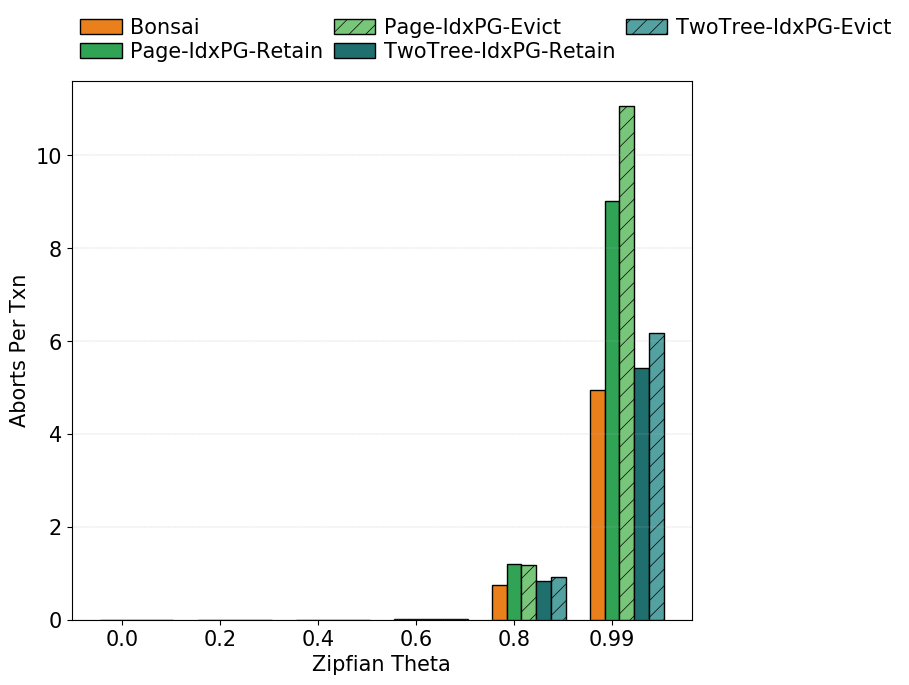

In [9]:
fig = plt.figure(figsize=(8, 7))

ax1 = fig.add_subplot(1, 1, 1)

# print(df_tuple["abort_cnt_"])
ax1.bar(index + 1 * bar_width, 
        df_tuple["abort_cnt_"]*1.0/df_tuple["txn_cnt_"], bar_width,edgecolor='black',
        color=bonsai_c,
        label="Bonsai")

ax1.bar(index + 2 * bar_width, 
        df_page["abort_cnt_"]*1.0/df_page["txn_cnt_"], bar_width, edgecolor='black',
        color=page_retain_c,
        label="Page-IdxPG-Retain")
ax1.bar(index + 3 * bar_width, 
        df_page_idx_evict["abort_cnt_"]*1.0/ df_page_idx_evict["txn_cnt_"], bar_width,edgecolor='black',
        color=page_evict_c,
        label="Page-IdxPG-Evict",hatch="//")
        # ax.plot(xval, 
        #         plot_data3.loc[y]["throughput_txn_per_sec"],
        #         color=line_colors["ORANGE"],
        #         marker=".", label="Remote-Index")

ax1.bar(index + 4 * bar_width, 
        df_tt["abort_cnt_"]*1.0/ df_tt["txn_cnt_"], bar_width,edgecolor='black',
        color=tt_retain_c,
        label="TwoTree-IdxPG-Retain")
ax1.bar(index + 5 * bar_width, 
        df_tt_idx_evict["abort_cnt_"]*1.0/df_tt_idx_evict["txn_cnt_"],bar_width,edgecolor='black',
        color=tt_evict_c,
        label="TwoTree-IdxPG-Evict",hatch="//")

ax1.set_xticks(df_tuple["zipf_theta_"])
plt.xticks(index + bar_width * (5 - 1) / 2, df_tuple["zipf_theta_"])

# location = "upper left"
location = "best"
# ax1.legend(loc=location, frameon=False)
# ax1.set_ylabel("Hit Ratio")
ax1.set_ylabel("Aborts Per Txn")
ax1.set_xlabel("Zipfian Theta")
# ax1.set_title("Abort Ratio Varying Theta (buf 25%, write-heavy)")

#ax.yaxis.set_major_formatter(mtick.FuncFormatter(y_axis_formatter))
ax1.grid(axis = 'y', linestyle = '--', linewidth = 0.25)
legend = plt.legend(bbox_to_anchor=(0., 1.03, 1.13, .102), loc=2,
           ncol=3,borderaxespad=0.,handletextpad=0.4,labelspacing=0.2, columnspacing=0.5, frameon=False)
plt.savefig("/home/hippo/Bonsai-private/paper/experiment/ev1-skew-rw-analysis-aborts.pdf",bbox_inches='tight')
